In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
users = pd.read_csv("all_users.csv")

transactions = pd.read_csv("all_transactions.csv")

recharge = pd.read_csv("recharge_bills.csv")

transfer = pd.read_csv("money_transfer.csv")

insurance = pd.read_csv("insurance.csv")

loans = pd.read_csv("loans.csv")

In [6]:
users.head()

,User_ID,Name,Age,Join_Date
0,PP0000001,Holly Rivera,56,2025-06-17
1,PP0000002,Kevin Lopez,46,2023-12-10
2,PP0000003,Douglas Roberts,32,2024-09-14
3,PP0000004,Walter Davila,60,2023-10-19
4,PP0000005,Grace Blake,25,2025-03-10


In [5]:
transactions.head()

,Transaction_ID,Amount,User_ID,Service,Service_Type,Payment_Status,Reason,Transaction_Date
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,6/9/2024
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,8/4/2024
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2/19/2024
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,12/22/2024
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,9/7/2024


In [7]:
transactions.shape

(300000, 8)

In [9]:
users.shape


(107658, 4)

In [10]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107658 entries, 0 to 107657
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   User_ID    107658 non-null  object
 1   Name       107658 non-null  object
 2   Age        107658 non-null  int64 
 3   Join_Date  107658 non-null  object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [11]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    300000 non-null  object 
 1   Amount            300000 non-null  float64
 2   User_ID           300000 non-null  object 
 3   Service           300000 non-null  object 
 4   Service_Type      300000 non-null  object 
 5   Payment_Status    300000 non-null  object 
 6   Reason            300000 non-null  object 
 7   Transaction_Date  300000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 18.3+ MB


In [12]:
users.describe()

,Age
count,107658.000000
mean,39.034628
std,12.382832
min,18.000000
25%,28.000000
50%,39.000000
75%,50.000000
max,60.000000


In [13]:
transactions.describe()

,Amount
count,300000.000000
mean,11581.073114
std,21376.115812
min,20.000000
25%,1345.587500
50%,3091.450000
75%,8769.805000
max,99999.010000


In [14]:
users.isnull().sum()

User_ID      0
Name         0
Age          0
Join_Date    0
dtype: int64

In [15]:
transactions.isnull().sum()

Transaction_ID      0
Amount              0
User_ID             0
Service             0
Service_Type        0
Payment_Status      0
Reason              0
Transaction_Date    0
dtype: int64

In [16]:
users.duplicated().sum()

np.int64(0)

In [17]:
transactions.duplicated().sum()

np.int64(0)

In [18]:
transactions.drop_duplicates(inplace=True)

In [19]:
users['Join_Date'] = pd.to_datetime(users['Join_Date'])

transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_Date']
)

In [20]:
transactions['Payment_Status'].unique()

array(['Successful', 'Failed', 'Wrong PIN', 'Insufficient amount',
       'Server error'], dtype=object)

In [21]:
transactions['Payment_Status'] = (
    transactions['Payment_Status']
    .str.strip()
    .str.title()
)

In [22]:
transactions['Month'] = (
    transactions['Transaction_Date']
    .dt.month_name()
)

In [23]:
transactions['Year'] = (
    transactions['Transaction_Date']
    .dt.year
)

In [24]:
transactions['Quarter'] = (
    transactions['Transaction_Date']
    .dt.quarter
)

In [25]:
transactions['Transaction_Category'] = pd.cut(
    transactions['Amount'],
    bins=[0,500,2000,5000,100000],
    labels=['Low','Medium','High','VIP']
)

In [26]:
today = pd.Timestamp.today()

users['Tenure_Days'] = (
    today - users['Join_Date']
).dt.days

In [27]:
transactions['Amount'].sum()

np.float64(3474321934.1600003)

In [28]:
transactions['Amount'].mean()

np.float64(11581.073113866667)

In [29]:
transactions['Amount'].max()

np.float64(99999.01)

In [30]:
transactions['Payment_Status'].value_counts()

Payment_Status
Successful             287993
Failed                   9980
Wrong Pin                 700
Server Error              692
Insufficient Amount       635
Name: count, dtype: int64

In [31]:
transactions.groupby('Service')['Amount'] \
            .sum() \
            .sort_values(ascending=False)

Service
Loans             2.532509e+09
Insurance         5.129230e+08
Money_Transfer    3.781946e+08
Recharge_Bills    5.069497e+07
Name: Amount, dtype: float64

In [32]:
transactions.groupby('Month')['Amount'] \
            .sum()

Month
April        2.835865e+08
August       2.902145e+08
December     2.861599e+08
February     2.788757e+08
January      2.934558e+08
July         3.044851e+08
June         2.863175e+08
March        2.927008e+08
May          2.960572e+08
November     2.846212e+08
October      2.949422e+08
September    2.829055e+08
Name: Amount, dtype: float64

In [33]:
transactions.groupby('User_ID')['Amount'] \
            .sum() \
            .sort_values(ascending=False) \
            .head(10)

User_ID
PP0028780    349166.69
PP1075901    341614.07
PP0019432    340158.16
PP1073199    339374.81
PP0035403    338375.08
PP0048328    336189.81
PP1053341    332905.46
PP0024185    330492.35
PP1052317    328541.64
PP1068113    327668.62
Name: Amount, dtype: float64

In [34]:
users['Age'].describe()

count    107658.000000
mean         39.034628
std          12.382832
min          18.000000
25%          28.000000
50%          39.000000
75%          50.000000
max          60.000000
Name: Age, dtype: float64

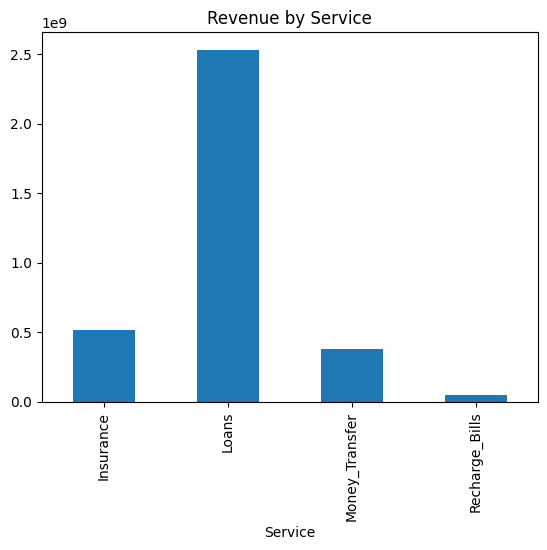

In [35]:
transactions.groupby('Service')['Amount'] \
            .sum() \
            .plot(kind='bar')

plt.title("Revenue by Service")
plt.show()

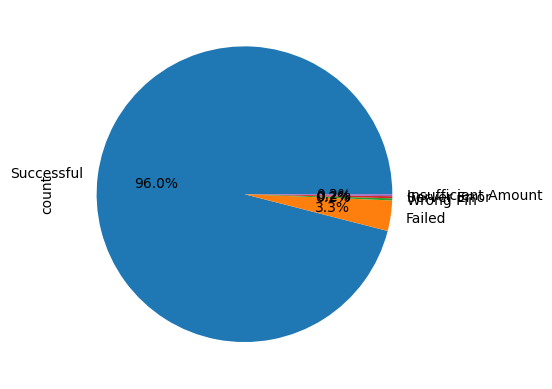

In [36]:
transactions['Payment_Status'] \
            .value_counts() \
            .plot(kind='pie',
                  autopct='%1.1f%%')

plt.show()

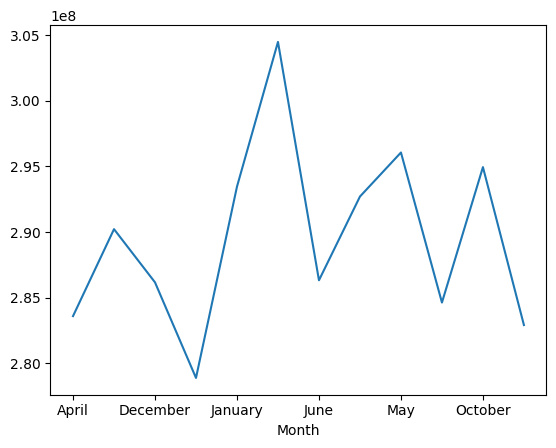

In [37]:
transactions.groupby('Month')['Amount'] \
            .sum() \
            .plot(kind='line')

plt.show()

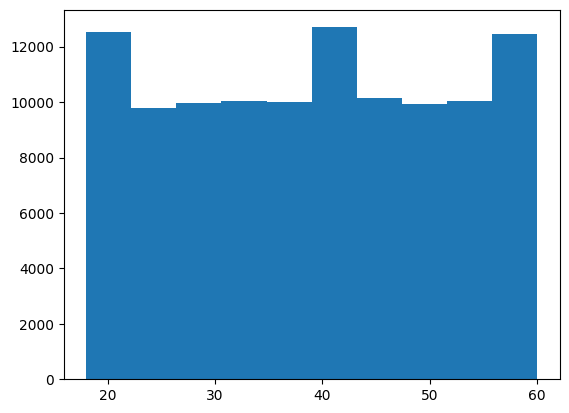

In [38]:
plt.hist(users['Age'])

plt.show()

1. Money Transfer generated the highest revenue.

2. Most transactions were successful.

3. Top 10 users contributed a significant share of revenue.

4. Revenue peaked during specific months.

5. Majority users belong to the 25–35 age group.